In [1]:
import os
import pandas as pd
import h5py

import matplotlib.pyplot as plt


from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import numpy as np

In [45]:
# Read the data

path = "./data/"

file_template = "Step2_REC.edm4hep_muon_halfgev.hdf5"

#file_template = "Step2_REC.edm4hep.hdf5"

file_path = os.path.join(path, file_template)

with h5py.File(file_path, 'r') as hdf_file:
    print(hdf_file.keys())
    mcParticle = hdf_file["MCParticles"]
    vertexBarrel = hdf_file["VertexBarrelCollection"]
    digi = hdf_file["VXDTrackerHits"]
    
    # Convert to DataFrame directly (no need for appending)
    df_mc = pd.DataFrame({dataset_name: mcParticle[dataset_name][:] for dataset_name in mcParticle.keys()})
    df_vertexBarrel = pd.DataFrame({dataset_name: vertexBarrel[dataset_name][:] for dataset_name in vertexBarrel.keys()})
    df_digi = pd.DataFrame({dataset_name: digi[dataset_name][:] for dataset_name in digi.keys()})
    
# Print the datasets and size
print(f"MCParticles: {df_mc.keys()}, shape: {df_mc.shape}")
print(f"VertexBarrelCollection: {df_vertexBarrel.keys()}, shape: {df_vertexBarrel.shape}")
print(f"VXDTrackerHits: {df_digi.keys()}, shape: {df_digi.shape}")


<KeysViewHDF5 ['MCParticles', 'VXDTrackerHits', 'VertexBarrelCollection']>
MCParticles: Index(['PDG', 'charge', 'daughters_begin', 'daughters_end', 'endpoint.x',
       'endpoint.y', 'endpoint.z', 'generatorStatus', 'mass', 'momentum.x',
       'momentum.y', 'momentum.z', 'momentumAtEndpoint.x',
       'momentumAtEndpoint.y', 'momentumAtEndpoint.z', 'parents_begin',
       'parents_end', 'simulatorStatusDG', 'time', 'vertex.x', 'vertex.y',
       'vertex.z'],
      dtype='object'), shape: (1500, 22)
VertexBarrelCollection: Index(['cellID', 'eDep', 'momentumX', 'momentumY', 'momentumZ', 'pathLength',
       'positionX', 'positionY', 'positionZ', 'quality', 'time'],
      dtype='object'), shape: (1500, 11)
VXDTrackerHits: Index(['VXDTrackerHits.u.a', 'VXDTrackerHits.u.b', 'VXDTrackerHits.v.a',
       'VXDTrackerHits.v.b', 'cellID', 'eDep', 'positionX', 'positionY',
       'positionZ', 'quality', 'time'],
      dtype='object'), shape: (1500, 11)


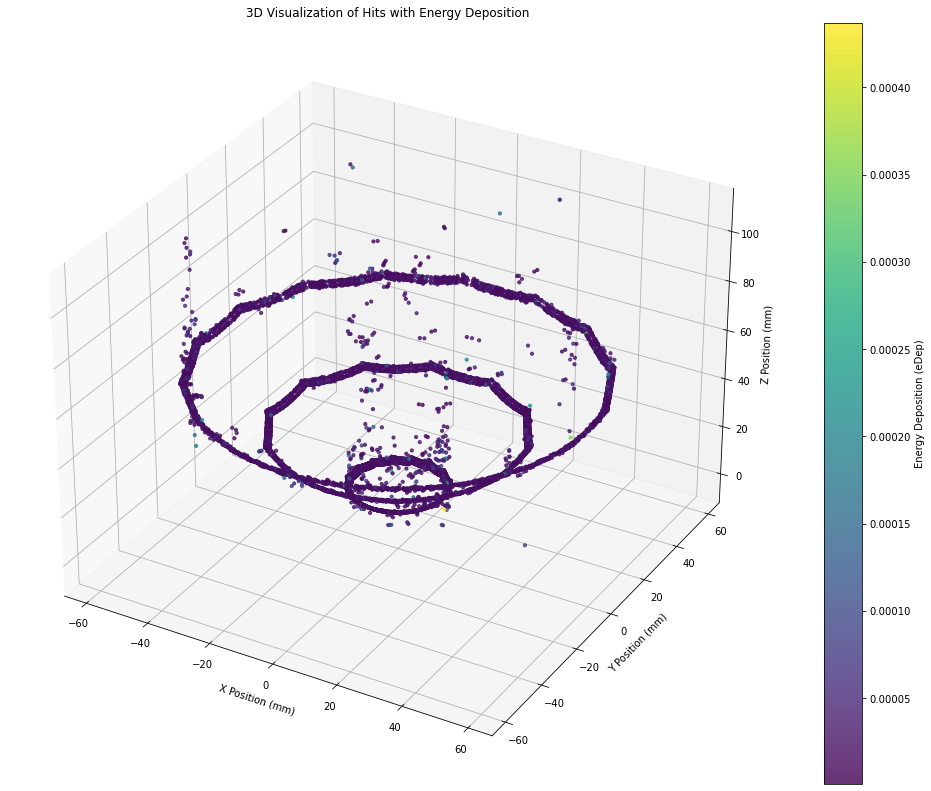

In [46]:
# Extract hit positions and energy deposition
x_positions = np.concatenate(df_digi["positionX"])
y_positions = np.concatenate(df_digi["positionY"])
z_positions = np.concatenate(df_digi["positionZ"])
eDep_values = np.concatenate(df_digi["eDep"])

# Create a 3D scatter plot
fig = plt.figure(figsize=(20, 14))
ax = fig.add_subplot(111, projection='3d')

# Use eDep for coloring or sizing
scatter = ax.scatter(x_positions, y_positions, z_positions, c=eDep_values, cmap='viridis', s=10, alpha=0.8)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Energy Deposition (eDep)')

# Add axis labels
ax.set_xlabel("X Position (mm)")
ax.set_ylabel("Y Position (mm)")
ax.set_zlabel("Z Position (mm)")

plt.title("3D Visualization of Hits with Energy Deposition")
#plt.savefig("./plots/hits_10geV_45degree.png")
plt.show()

In [47]:
# interactive visualization of the hits

x_positions = np.concatenate(df_digi["positionX"])
y_positions = np.concatenate(df_digi["positionY"])
z_positions = np.concatenate(df_digi["positionZ"])
eDep_values = np.concatenate(df_digi["eDep"])

# Create a 3D interactive scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_positions,
    y=y_positions,
    z=z_positions,
    mode='markers',
    marker=dict(
        size=3,
        color=eDep_values,  # color by energy deposition
        colorscale='Viridis',
        colorbar=dict(title='eDep'),
        opacity=0.8
    )
)])

fig.update_layout(
    title=" ",
    scene=dict(
        xaxis_title='X (mm)',
        yaxis_title='Y (mm)',
        zaxis_title='Z (mm)',
    ),
    width=800,
    height=600
)

#plt.savefig('./plots/hit_plot_10geV_muons.png')
fig.show()


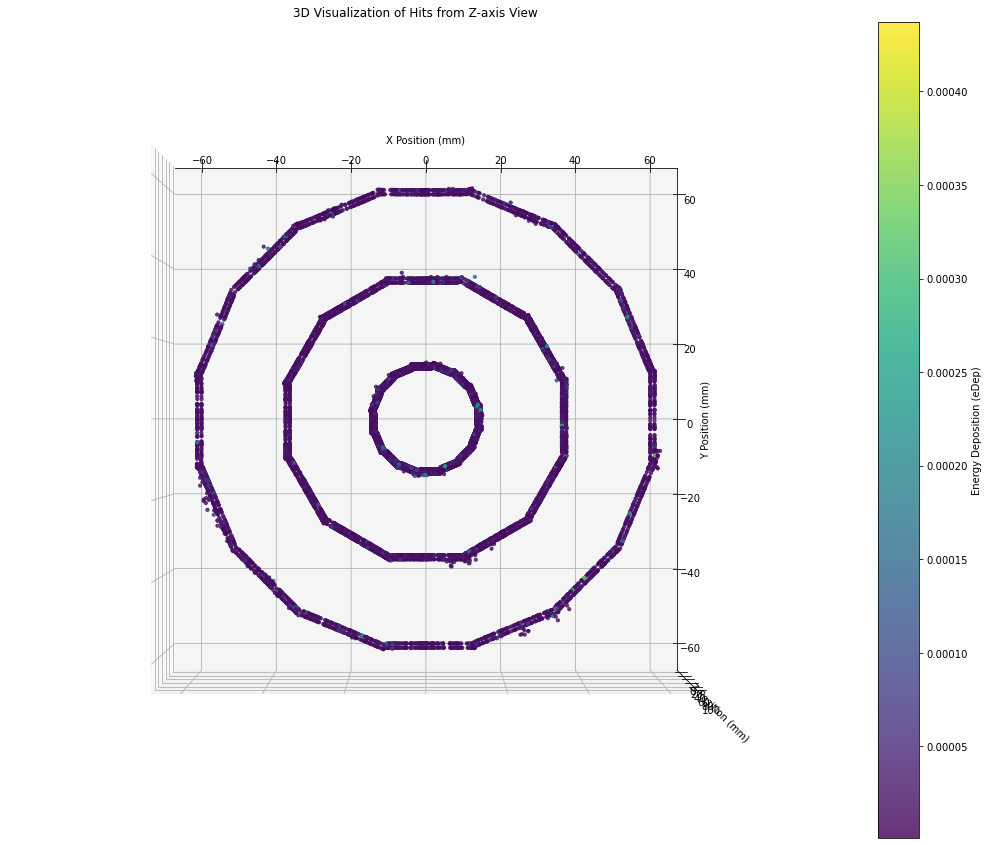

In [48]:
# view along Z axis
x_positions = np.concatenate(df_digi["positionX"])
y_positions = np.concatenate(df_digi["positionY"])
z_positions = np.concatenate(df_digi["positionZ"])
eDep_values = np.concatenate(df_digi["eDep"])

# Create a 3D scatter plot
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with energy deposition as color
scatter = ax.scatter(x_positions, y_positions, z_positions, c=eDep_values, cmap='viridis', s=10, alpha=0.8)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Energy Deposition (eDep)')

# Set axis labels
ax.set_xlabel("X Position (mm)")
ax.set_ylabel("Y Position (mm)")
ax.set_zlabel("Z Position (mm)")

# Rotate the view to look along the Z-axis
ax.view_init(elev=90, azim=-90)  # Adjust elevation and azimuth for Z-axis view

plt.title("3D Visualization of Hits from Z-axis View")
plt.show()

In [49]:
# Calculate radius for each entry
df_digi["radius_l0"] = [np.sqrt(np.array(x)**2 + np.array(y)**2) for x, y in zip(df_digi['positionX'], df_digi['positionY'])]

## select only the innermost layer and convert to cylindrical coordinate

In [50]:
df_digil0 = []  

for index, row in df_digi.iterrows():
    r_val = row["radius_l0"]
    x_val = row["positionX"]
    y_val = row["positionY"]
    z_val = row["positionZ"]
    eDep_val = row["eDep"]
    cellID_val = row["cellID"]
    
    #list to store each row data
    row_data = {
        "positionX": [],
        "positionY": [],
        "positionZ": [],
        "eDep": [],
        "cellID":[],
        "radius": []
    }
    
    
    #filter based on radius threshold
    for r, x, y, z, e, c in zip(r_val, x_val, y_val, z_val, eDep_val, cellID_val):
        if r < 20:  ## old file 200
            row_data["positionX"].append(x)
            row_data["positionY"].append(y)
            row_data["positionZ"].append(z)
            row_data["eDep"].append(e)
            row_data["radius"].append(r)
            row_data["cellID"].append(c)
    
    #append to the main list
    df_digil0.append(row_data)
            

#convert filtered values to pandas
df_digil0 = pd.DataFrame(df_digil0)

In [51]:
pd.set_option('display.max_rows', 100)
# df_vertexBarrel.head(20)

In [55]:
#df_digi.head(10)

In [56]:
#df_digil0.head(30)

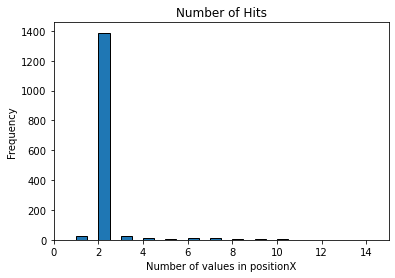

In [57]:
# Count number of elements in each row
df_digil0["count"] = df_digil0["positionX"].apply(len)

# Plot histogram
plt.hist(df_digil0["count"], bins=50, edgecolor="black")
plt.xlabel("Number of values in positionX")
plt.ylabel("Frequency")
plt.title("Number of Hits")
plt.xlim(0,15)
#plt.savefig("./plots/hits_10GeV.png")
plt.show()

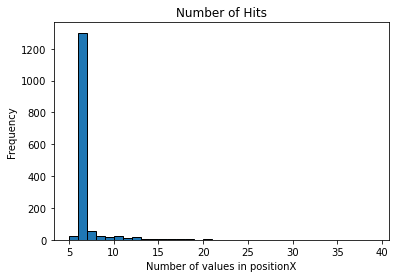

In [16]:
# Example: df_digil0 is your dataframe
# Count number of elements in each row
df_digi["count"] = df_digi["positionX"].apply(len)

# Plot histogram
plt.hist(df_digi["count"], bins=range(df_digi["count"].min(), df_digi["count"].max()+2), edgecolor="black")
plt.xlabel("Number of values in positionX")
plt.ylabel("Frequency")
plt.title("Number of Hits")
plt.savefig("./plots/hits_half_geV_unfiltered.png")
plt.show()

In [76]:
# view along Z axis (Innermost layer)
x_positions = np.concatenate(df_vertexBarrell0["positionX"])
y_positions = np.concatenate(df_vertexBarrell0["positionY"])

plt.figure(figsize=(12, 10))
plt.hist2d(x_positions, y_positions, bins=250, cmap='viridis')
plt.colorbar(label=" ")
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
#plt.savefig('./plots/inner_layer_hit.png')
plt.show()

NameError: name 'df_vertexBarrell0' is not defined

In [77]:
df_vertexBarrell0.head(20)

NameError: name 'df_vertexBarrell0' is not defined

In [78]:
df_digi.head()

,VXDTrackerHits.u.a,VXDTrackerHits.u.b,VXDTrackerHits.v.a,VXDTrackerHits.v.b,cellID,eDep,positionX,positionY,positionZ,quality,time,radius_l0,count
0,"[1.5707964, 1.5707964, 1.5707964, 1.5707964, 1...","[-1.1780972, -1.1780972, -1.0471976, -1.047197...","[6.123234e-17, 6.123234e-17, 6.123234e-17, 6.1...","[0.3926991, 0.3926991, 0.5235988, 0.5235988, 0...","[73729, 73857, 57601, 57729, 74241, 74369]","[1.6596456e-05, 1.7187205e-05, 1.4898762e-05, ...","[-11.689795, -12.610319, -30.5976, -31.49156, ...","[-6.4283886, -6.949829, -17.5234, -18.075018, ...","[13.329345, 14.376945, 34.997734, 36.032745, 5...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.06441852, 0.06949546, 0.16952403, 0.1745525...","[13.340745, 14.398621, 35.260216, 36.310116, 5...",6
1,"[1.5707964, 1.5707964, 1.5707964, 1.5707964, 1...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[6.123234e-17, 6.123234e-17, 6.123234e-17, 6.1...","[1.5707964, 1.5707964, 1.5707964, 1.5707964, 1...","[98305, 98433, 73985, 74113, 98817, 98945, 988...","[1.743709e-05, 1.3428498e-05, 2.2150498e-05, 1...","[-0.97097015, -1.0247191, -1.9342247, -1.96019...","[-13.26, -14.31, -35.26, -36.31, -57.26, -58.3...","[13.275887, 14.315997, 34.9633, 35.996735, 56....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.06417564, 0.06921959, 0.16956164, 0.1745836...","[13.295503, 14.3466425, 35.31301, 36.362873, 5...",9
2,"[1.5707964, 1.5707964, 1.5707964, 1.5707964, 1...","[0.7853982, 0.7853982, 1.0471976, 1.0471976, 0...","[6.123234e-17, 6.123234e-17, 6.123234e-17, 6.1...","[2.3561945, 2.3561945, 2.6179938, 2.6179938, 2...","[114689, 114817, 90369, 90497, 115201, 115329]","[1.4901157e-05, 1.2324159e-05, 1.7588462e-05, ...","[9.581514, 10.351357, 26.595083, 27.403358, 42...","[-9.170958, -9.886039, -24.455965, -25.15599, ...","[13.271674, 14.32244, 36.143505, 37.2114, 57.3...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.06409056, 0.06915623, 0.1743694, 0.17952336...","[13.263178, 14.313783, 36.13022, 37.199028, 57...",6
3,"[1.5707964, 1.5707964, 1.5707964, 1.5707964, 1...","[-1.5707964, -1.5707964, -1.5707964, -1.570796...","[6.123234e-17, 6.123234e-17, 6.123234e-17, 6.1...","[-1.8369701e-16, -1.8369701e-16, -1.8369701e-1...","[65537, 65665, 49409, 49537, 66049, 66177]","[1.8972964e-05, 1.8674567e-05, 2.056018e-05, 2...","[-13.26, -14.31, -35.26, -36.31, -57.26, -58.31]","[1.29597, 1.3752934, 2.734091, 2.784091, 3.342...","[13.3236265, 14.37621, 35.29093, 36.33749, 57....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.064359054, 0.06943586, 0.1704749, 0.1755332...","[13.32318, 14.3759365, 35.36584, 36.416584, 57...",6
4,"[1.5707964, 1.5707964, 1.5707964, 1.5707964, 1...","[2.3561945, 2.3561945, 2.6179938, 2.6179938, 2...","[6.123234e-17, 6.123234e-17, 6.123234e-17, 6.1...","[-2.3561945, -2.3561945, -2.0943952, -2.094395...","[16385, 16513, 16641, 16769, 16897, 17025]","[1.6168377e-05, 2.9712754e-05, 1.3666549e-05, ...","[7.976182, 8.596569, 20.53906, 21.12901, 32.78...","[10.77629, 11.640827, 28.856508, 29.728336, 48...","[13.42396, 14.491421, 35.547245, 36.60808, 58....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.06480962, 0.06994642, 0.17122318, 0.1763177...","[13.40701, 14.471001, 35.419643, 36.47203, 58....",6


In [79]:
import plotly.express as px
# Flatten lists from df_digil0
x_all = np.concatenate(df_vertexBarrell0["positionX"])
y_all = np.concatenate(df_vertexBarrell0["positionY"])
z_all = np.concatenate(df_vertexBarrell0["positionZ"])
e_all = np.concatenate(df_vertexBarrell0["eDep"])
cell_all = np.concatenate(df_vertexBarrell0["cellID"])

# Create DataFrame
df_hits = pd.DataFrame({
    "x": x_all,
    "y": y_all,
    "z": z_all,
    "eDep": e_all,
    "cellID": cell_all.astype(str)  # for better legend grouping
})

# Plot
fig = px.scatter(
    df_hits,
    x="x",
    y="y",
    color="cellID",
    hover_data=["x", "y", "z", "eDep", "cellID"],
    title="Interactive View of Sensor Hits by cellID",
    width=900,
    height=800
)

fig.update_traces(marker=dict(size=5), selector=dict(mode='markers'))
fig.update_layout(legend_title_text='cellID')
fig.show()



NameError: name 'df_vertexBarrell0' is not defined

### Sensor Positions of Innermost Layer

In [80]:
# Add 'phi' column to the DataFrame
df_vertexBarrell0['phi'] = df_vertexBarrell0.apply(
    lambda row: [np.arctan2(y, x) for x, y in zip(row['positionX'], row['positionY'])],
    axis=1
)

NameError: name 'df_vertexBarrell0' is not defined

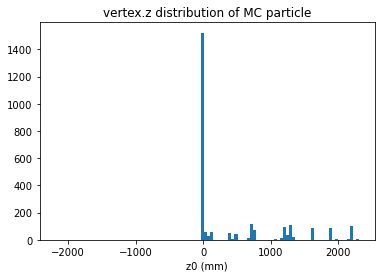

In [81]:
z_dist = np.concatenate(df_mc["vertex.z"])
plt.hist(z_dist,bins=100)
plt.title("vertex.z distribution of MC particle")
plt.xlabel("z0 (mm)")
#plt.xlim(-100,100)
plt.show()

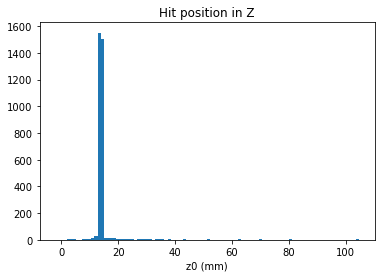

In [82]:
z_dist = np.concatenate(df_digil0["positionZ"])
plt.hist(z_dist,bins=100)
plt.title("Hit position in Z")
plt.xlabel("z0 (mm)")
#plt.xlim(-100,100)
plt.show()

### Filter muon tracks

In [83]:
def filter_muons(df_mc):
    """
    Filters only muon (PDG = ±13) tracks from MCParticle dataset.
    """
    muons = []
    
    for idx, row in df_mc.iterrows():
        pdg = np.array(row["PDG"])
        charge = np.array(row["charge"])
        gen_status = np.array(row["generatorStatus"])
        
        # Select only muons (PDG = ±13)
        #muon_mask = (np.abs(pdg) == 13)& (gen_status == 1)  
        muon_mask = np.abs(pdg) == 13
        
        #muon_mask = np.isin(np.abs(pdg),[13,11,22]) 
        
        if np.any(muon_mask):
            muons.append({
                "PDG": pdg[muon_mask],
                "charge": charge[muon_mask],
                "x0": np.array(row["vertex.x"])[muon_mask],
                "y0": np.array(row["vertex.y"])[muon_mask],
                "z0": np.array(row["vertex.z"])[muon_mask],
                "px": np.array(row["momentum.x"])[muon_mask],
                "py": np.array(row["momentum.y"])[muon_mask],
                "pz": np.array(row["momentum.z"])[muon_mask],
                "mass": np.array(row["mass"])[muon_mask],
                "genStatus": np.array(row["generatorStatus"])[muon_mask]
            })
    
    return pd.DataFrame(muons)

# Apply the function
df_mcMuons = filter_muons(df_mc)

In [84]:
#fraction of soft particles
check_pdg = df_mcMuons["PDG"]

In [85]:
check_pdg[0]

array([13], dtype=int32)

In [86]:
type(check_pdg)

pandas.core.series.Series

In [87]:
all_values = np.concatenate(check_pdg)

In [88]:
count = np.sum((all_values==13) | (all_values==-13))

In [89]:
print(f"fraction of muons hits: {count/len(all_values)*100:.3g}%")

fraction of muons hits: 100%


In [90]:
# count number of hits> 1 per row
count_multiple_pdg = df_mcMuons['PDG'].apply(lambda x: isinstance(x, list) and len(x) > 1).sum()

print(f"Number of rows with more than one PDG: {count_multiple_pdg}")


Number of rows with more than one PDG: 0


In [91]:
def compute_track_parameters(df_mcMuons):
    
    pT_list, theta_list, phi_list, tan_lambda_list = [], [], [], []

    # Iterate through each row
    for _, row in df_mcMuons.iterrows():
        px, py, pz = np.array(row["px"]), np.array(row["py"]), np.array(row["pz"])
        
        # Compute pT, theta, phi, and tan_lambda
        pT = np.sqrt(px**2 + py**2)
        theta = np.arctan2(pT, pz)
        phi = np.arctan2(py, px)
        tan_lambda = pz / pT

        # Append results
        pT_list.append(pT.tolist())
        theta_list.append(theta.tolist())
        phi_list.append(phi.tolist())
        tan_lambda_list.append(tan_lambda.tolist())

    # update the dataframe with new columns
    df_mcMuons["pT"] = pT_list
    df_mcMuons["theta"] = theta_list
    df_mcMuons["phi"] = phi_list
    df_mcMuons["tan_lambda"] = tan_lambda_list

    return df_mcMuons  # Returns updated DataFrame

# **Run function to update df_mcMuons**
df_mcMuons = compute_track_parameters(df_mcMuons)

In [92]:
df_mcMuons.head(4)

,PDG,charge,x0,y0,z0,px,py,pz,mass,genStatus,pT,theta,phi,tan_lambda
0,[13],[-1],[0.0],[0.0],[0.0],[-0.311603],[-0.16704361],[0.35355338],[0.105658375],[1],[0.3535533845424652],[0.7853981852531433],[-2.649500608444214],[1.0]
1,[13],[-1],[0.0],[0.0],[0.0],[-0.029263588],[-0.35234025],[0.35355338],[0.105658375],[1],[0.3535534143447876],[0.7853982448577881],[-1.6536610126495361],[0.9999999403953552]
2,[13],[-1],[0.0],[0.0],[0.0],[0.25274387],[-0.24722567],[0.35355338],[0.105658375],[1],[0.3535533845424652],[0.7853981852531433],[-0.7743615508079529],[1.0]
3,[13],[-1],[0.0],[0.0],[0.0],[-0.35148755],[0.038164284],[0.35355338],[0.105658375],[1],[0.3535533845424652],[0.7853981852531433],[3.0334370136260986],[1.0]


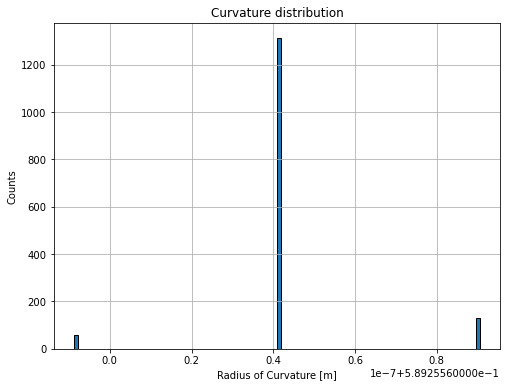

In [93]:
B = 2  # Tesla
radius = df_mcMuons["pT"].apply(lambda r: np.array(r) / (0.3 * B))

# Flatten all arrays in 'radius' into a single array
radius_values = np.concatenate(radius.values)

# Plotting the histogram of radius values
plt.figure(figsize=(8, 6))
plt.hist(radius_values, bins=100, edgecolor='black')
plt.xlabel("Radius of Curvature [m]")
plt.ylabel("Counts")
plt.title("Curvature distribution")
plt.grid(True)
plt.show()

In [94]:
df_mcMuons = df_mcMuons[:1500]
df_digil0 = df_digil0[:1500]

### MC Particle interaction in the sensors

In [95]:
B = 2  # inner_field (Solenoid Field) in hepSim website

def compute_track_intersections(df_mcMuons, df_digil0):
    intersections = []

    
    for hit_index, hit_row in df_digil0.iterrows():
        x_hit_values = np.array(hit_row["positionX"])
        y_hit_values = np.array(hit_row["positionY"])
        z_hit_values = np.array(hit_row["positionZ"])
        
        #added later tupen
        cellID_hit_values = np.array(hit_row["cellID"])
            
        for i in range(len(x_hit_values)):
            x_hit = x_hit_values[i]
            y_hit = y_hit_values[i]
            z_hit = z_hit_values[i]
            
            cellID_hit = cellID_hit_values[i]


            dist = -1.
            
            for track_index, track_row in df_mcMuons.iterrows():
                x0_values = np.array(track_row["x0"])
                y0_values = np.array(track_row["y0"])
                z0_values = np.array(track_row["z0"])
                pT_values = np.array(track_row["pT"]) 
                phi0_values = np.array(track_row["phi"])
                charge_values = np.array(track_row["charge"])
                theta_values = np.array(track_row["theta"])
                tan_lambda_values = np.array(track_row["tan_lambda"]) 
                lambda_angle_values = np.arctan(tan_lambda_values)

                R_values = np.array(pT_values/0.3*B)  #  R = pT/(0.3qB)
                
                for muon_index in range(len(x0_values)):
                    charge = charge_values[muon_index]
                    x0 = x0_values[muon_index]
                    z0 = z0_values[muon_index]    
                    y0 = y0_values[muon_index]
                    pT = pT_values[muon_index]
                    phi0 = phi0_values[muon_index]
                    tan_lambda = tan_lambda_values[muon_index]
                    lambda_angle = lambda_angle_values[muon_index]
                    theta_angle = theta_values[muon_index]
                    R = R_values[muon_index]*1000 ##mm

                    
                    psi = (z_hit - z0)* charge* np.tan(theta_angle)/R
                    
                    x_intersect = x0 + R*np.sin(psi + phi0) - R*np.sin(phi0)
                    y_intersect = y0 + R*np.cos(psi + phi0) - R*np.cos(phi0)
                    z_intersect = z0 + (R * psi)/(np.tan(theta_angle))
                    
                    resid = np.sqrt((x_intersect-x_hit)**2 + (y_intersect-y_hit)**2 + (z_intersect-z_hit)**2 )

                    if (dist < 0 ) or resid < dist: 
                        dist = resid
                        min_track_index = track_index
                        min_x_intersect = x_intersect
                        min_y_intersect = y_intersect
                        min_z_intersect = z_intersect
                        pT_value = pT
                        phi0_value = phi0
                        cellID_min = cellID_hit
                
            # Store with proper indexing information
            if dist >= 0:
                intersections.append({
                    "hit_index": hit_index,
                    "sensor_hit_index": i,
                    "track_index": min_track_index,
                    "x_intersect": min_x_intersect,
                    "y_intersect": min_y_intersect,
                    "z_intersect": min_z_intersect,
                    "x_hit": x_hit,
                    "y_hit": y_hit,
                    "z_hit": z_hit,
                    "pT": pT_value,
                    "phi0": phi0_value,
                    "cellID": cellID_min,
                    "distance": dist
                })
    
    return pd.DataFrame(intersections)

# # Run function
df_track_intersections = compute_track_intersections(df_mcMuons, df_digil0)
df_track_intersections["z_intersect"] = df_track_intersections["z_intersect"].abs()

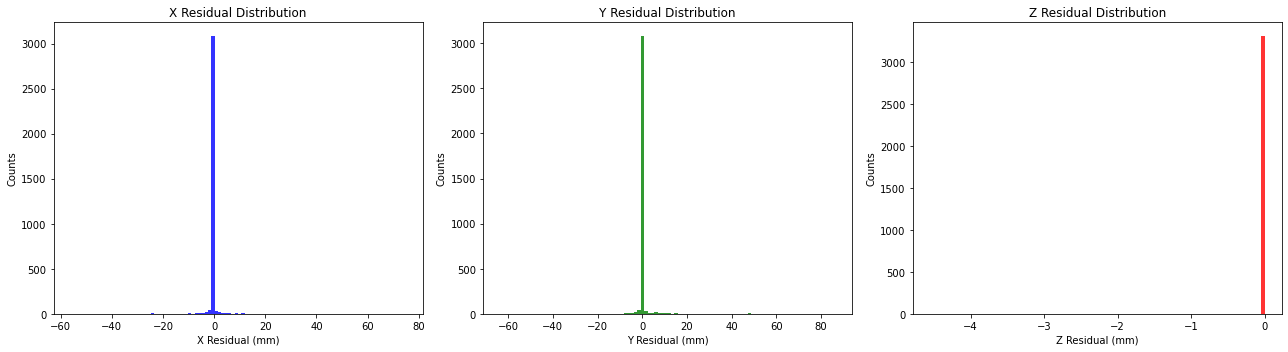

In [96]:
# Flatten residual arrays
x_residuals = df_track_intersections["x_hit"] - df_track_intersections["x_intersect"]
y_residuals = df_track_intersections["y_hit"] - df_track_intersections["y_intersect"]
z_residuals = df_track_intersections["z_hit"] - df_track_intersections["z_intersect"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# X residuals
axes[0].hist(x_residuals, bins=100, alpha=0.8, color='blue')
axes[0].set_title('X Residual Distribution')
axes[0].set_xlabel('X Residual (mm)')
axes[0].set_ylabel('Counts')

# Y residuals
axes[1].hist(y_residuals, bins=100, alpha=0.8, color='green')
axes[1].set_title('Y Residual Distribution')
axes[1].set_xlabel('Y Residual (mm)')
axes[1].set_ylabel('Counts')

# Z residuals
axes[2].hist(z_residuals, bins=100, alpha=0.8, color='red')
axes[2].set_title('Z Residual Distribution')
axes[2].set_xlabel('Z Residual (mm)')
axes[2].set_ylabel('Counts')

plt.tight_layout()
#plt.savefig("./plots/residual_genStat_1.png")
plt.show()


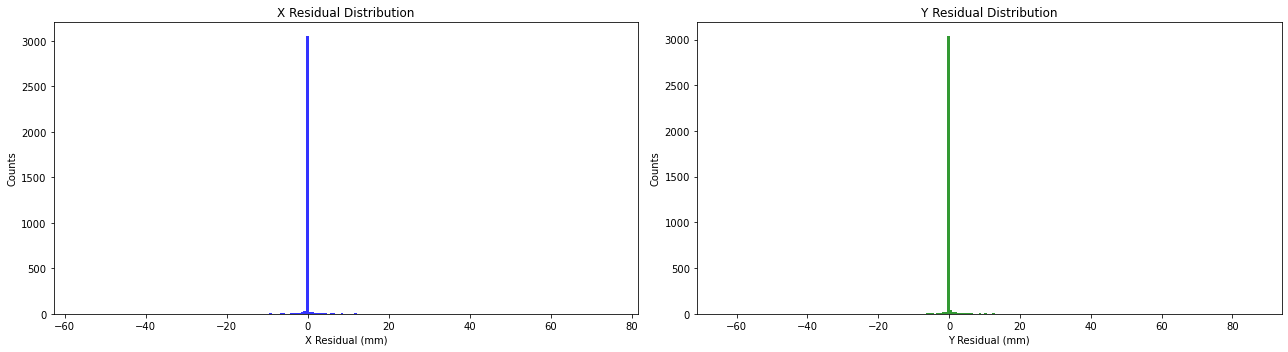

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# X residuals
axes[0].hist(x_residuals, bins=200, alpha=0.8, color='blue')
axes[0].set_title('X Residual Distribution')
axes[0].set_xlabel('X Residual (mm)')
axes[0].set_ylabel('Counts')
#axes[0].set_xlim(-1, 1)  # 

# Y residuals
axes[1].hist(y_residuals, bins=200, alpha=0.8, color='green')
axes[1].set_title('Y Residual Distribution')
axes[1].set_xlabel('Y Residual (mm)')
axes[1].set_ylabel('Counts')
#axes[1].set_xlim(-1,1)  # 

plt.tight_layout()
#plt.savefig("./plots/residual_vertex_10geV.png")
plt.show()

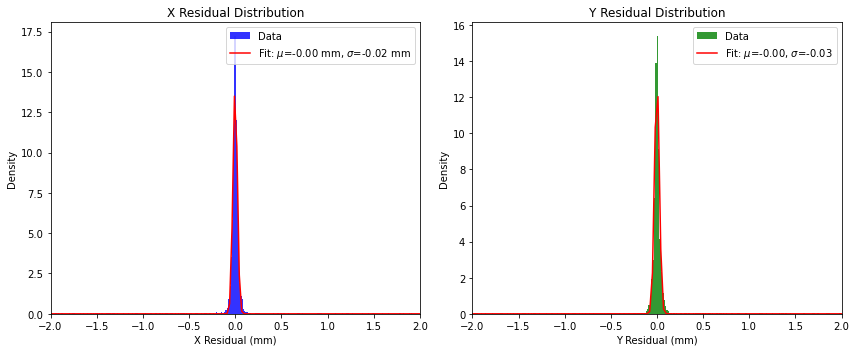

In [98]:
# fit to the residuals

from scipy.optimize import curve_fit

# Define Gaussian function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Fit Gaussian to histogram data
def fit_gaussian(data, bins=5000):
    hist, bin_edges = np.histogram(data, bins=bins, density=True)  # Get histogram
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Compute bin centers

    # Initial guess for fitting [Amplitude, Mean, Sigma]
    p0 = [max(hist), np.mean(data), np.std(data)] 

    # Fit Gaussian
    popt, _ = curve_fit(gaussian, bin_centers, hist, p0=p0)

    return popt, bin_centers, hist

# Fit X and Y residuals
popt_x, x_bin_centers, x_hist = fit_gaussian(x_residuals)
popt_y, y_bin_centers, y_hist = fit_gaussian(y_residuals)

# Plot residual distributions with Gaussian fits
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# X residuals
axes[0].hist(x_residuals, bins=10000, alpha=0.8, color='blue', density=True, label="Data")
axes[0].plot(x_bin_centers, gaussian(x_bin_centers, *popt_x), 'r-', label=f'Fit: $\mu$={popt_x[1]:.2f} mm, $\sigma$={popt_x[2]:.2f} mm')
axes[0].set_title('X Residual Distribution')
axes[0].set_xlabel('X Residual (mm)')
axes[0].set_ylabel('Density')
axes[0].set_xlim(-2, 2)
axes[0].legend(loc='upper right')

# Y residuals
axes[1].hist(y_residuals, bins=10000, alpha=0.8, color='green', density=True, label="Data")
axes[1].plot(y_bin_centers, gaussian(y_bin_centers, *popt_y), 'r-', label=f'Fit: $\mu$={popt_y[1]:.2f}, $\sigma$={popt_y[2]:.2f}')
axes[1].set_title('Y Residual Distribution')
axes[1].set_xlabel('Y Residual (mm)')
axes[1].set_ylabel('Density')
axes[1].set_xlim(-2, 2)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig("./plots/fitted_residual_newSim_muon_10geV.png")
plt.show()

In [99]:
pT = df_track_intersections["pT"]
phi0 = df_track_intersections["phi0"]
x_hit = df_track_intersections["x_hit"]
y_hit = df_track_intersections["y_hit"]
z_hit = df_track_intersections["z_hit"]

#### Dependency with x_hit, y_hit, z_hit?

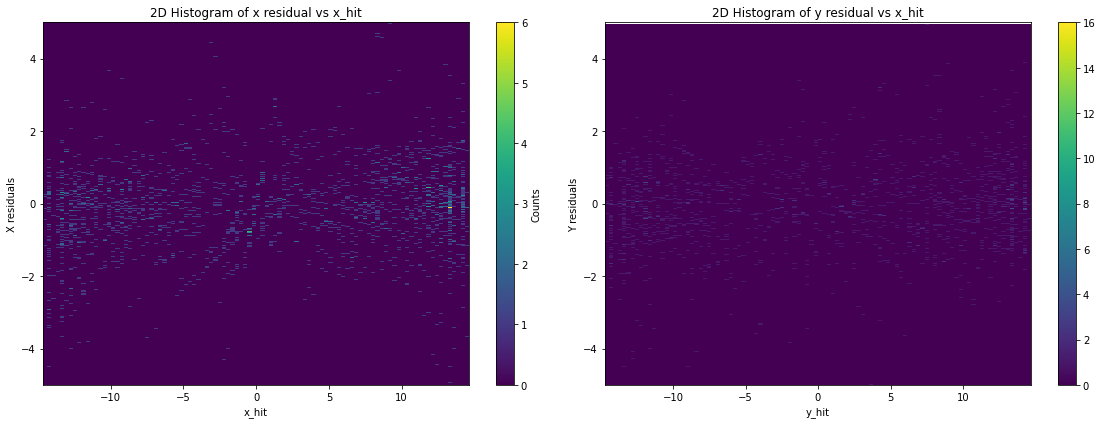

In [108]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# First plot: x residual vs pT
h1 = axs[0].hist2d(x_hit, x_residuals, bins = [100,500], cmap='viridis')
axs[0].set_xlabel('x_hit')
axs[0].set_ylabel('X residuals')
axs[0].set_title('2D Histogram of x residual vs x_hit')
axs[0].set_ylim(-5,5)
plt.colorbar(h1[3], ax=axs[0], label='Counts')

# Second plot: y residual vs pT
h2 = axs[1].hist2d(y_hit, y_residuals, bins= [100,500], cmap='viridis')
axs[1].set_xlabel('y_hit')
axs[1].set_ylabel('Y residuals')
axs[1].set_title('2D Histogram of y residual vs x_hit')
axs[1].set_ylim(-5,5)
plt.colorbar(h2[3], ax=axs[1])

plt.tight_layout()
#plt.savefig("plots/residual_hit_10gev.png")
plt.show()

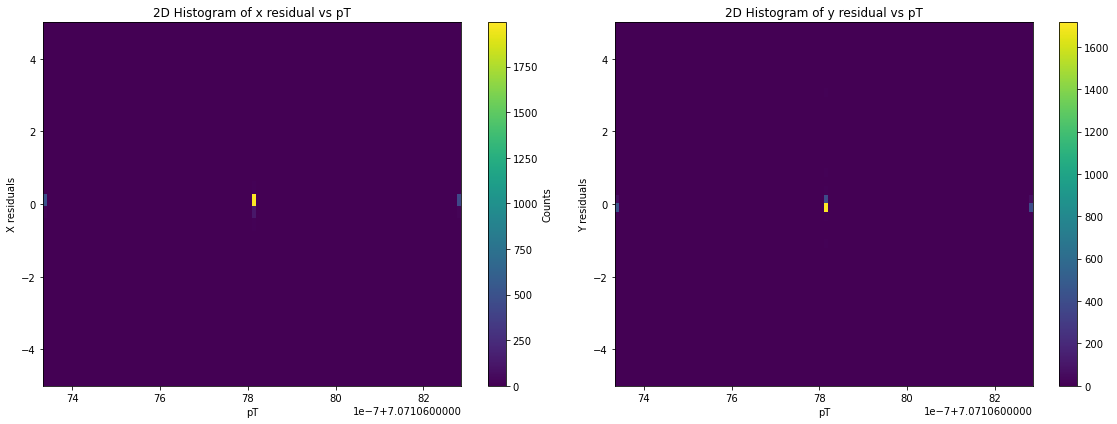

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# First plot: x residual vs pT
h1 = axs[0].hist2d(pT, x_residuals, bins = [100,500], cmap='viridis')
axs[0].set_xlabel('pT')
axs[0].set_ylabel('X residuals')
axs[0].set_title('2D Histogram of x residual vs pT')
axs[0].set_ylim(-5,5)
plt.colorbar(h1[3], ax=axs[0], label='Counts')

# Second plot: y residual vs pT
h2 = axs[1].hist2d(pT, y_residuals, bins=[100,500], cmap='viridis')
axs[1].set_xlabel('pT')
axs[1].set_ylabel('Y residuals')
axs[1].set_title('2D Histogram of y residual vs pT')
axs[1].set_ylim(-5,5)
plt.colorbar(h2[3], ax=axs[1])

plt.tight_layout()
#plt.savefig("plots/residual_vs_pT_10gev.png")
plt.show()

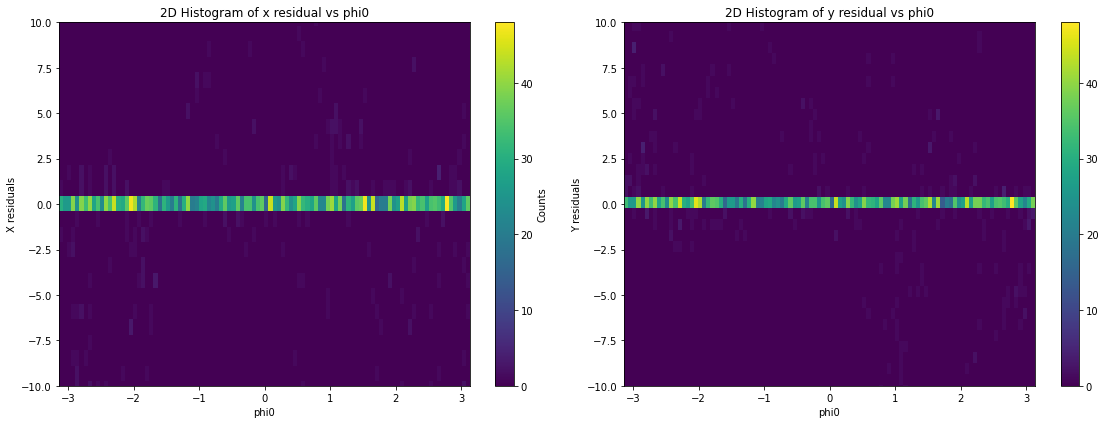

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# First plot: x residual vs pT
h1 = axs[0].hist2d(phi0, x_residuals, bins=[100,200], cmap='viridis')
axs[0].set_xlabel('phi0')
axs[0].set_ylabel('X residuals')
axs[0].set_title('2D Histogram of x residual vs phi0')
axs[0].set_ylim(-10,10)
plt.colorbar(h1[3], ax=axs[0], label='Counts')

# Second plot: y residual vs pT
h2 = axs[1].hist2d(phi0, y_residuals, bins=[100,200], cmap='viridis')
axs[1].set_xlabel('phi0')
axs[1].set_ylabel('Y residuals')
axs[1].set_title('2D Histogram of y residual vs phi0')
axs[1].set_ylim(-10,10)
plt.colorbar(h2[3], ax=axs[1])

plt.tight_layout()
#plt.savefig("plots/residual_vs_phi0_10gev.png")
plt.show()

In [43]:
## open the sensor position files

#file = '../sensor_position_L0.csv'

#vertex sensor position 
file = '../vertex_sensor_position_L0.csv'
df_sensor = pd.read_csv(file)

In [44]:
df_sensor.head()

,Sensor,x (cm),y (cm),z (cm)
0,1,1.326000,0.112903,0.0
1,3,1.181858,0.611747,0.0
2,5,0.857789,1.017458,0.0
3,7,0.403129,1.268270,0.0
4,9,-0.112903,1.326000,0.0


In [45]:
# add positions in mm too

df_sensor['x_mm'] = df_sensor['x (cm)'] * 10
df_sensor['y_mm'] = df_sensor['y (cm)'] * 10
df_sensor['z_mm'] = df_sensor['z (cm)'] * 10

In [38]:
df_sensor.head()

,Sensor,x (cm),y (cm),z (cm),x_mm,y_mm,z_mm
0,0,12.7,0.0,-46.655,127.0,0.0,-466.55
1,1,12.7,0.0,-43.645,127.0,0.0,-436.45
2,2,12.7,0.0,-40.635,127.0,0.0,-406.35
3,3,12.7,0.0,-37.625,127.0,0.0,-376.25
4,4,12.7,0.0,-34.615,127.0,0.0,-346.15


## visualize sensor positions

In [39]:
#visualize sensor positions

# fig = go.Figure(data=go.Scatter3d(
#     x=df_sensor['x_mm'],
#     y=df_sensor['y_mm'],
#     z=df_sensor['z_mm'],
#     mode='markers',
#     marker=dict(
#         size=3,
#         color=df_sensor['z_mm'],  # color by z-position
#         colorscale='Viridis',
#         opacity=0.8
#     ),
#     text=[f"Sensor ID: {sid}" for sid in df_sensor["Sensor"]]
# ))

# fig.update_layout(
#     title="Interactive 3D Sensor Layout",
#     scene=dict(
#         xaxis_title='X (mm)',
#         yaxis_title='Y (mm)',
#         zaxis_title='Z (mm)'
#     ),
#     margin=dict(l=0, r=0, b=0, t=40)
# )

# fig.show()

In [40]:
df_track_intersections.head(5)

,hit_index,sensor_hit_index,track_index,x_intersect,y_intersect,z_intersect,x_hit,y_hit,z_hit,pT,phi0,cellID,distance
0,0,0,573,1.779889,-13.259450,13.378380,1.775799,-13.260000,13.378380,7.071067,-1.704092,98305,26.756760
1,0,1,573,1.921040,-14.309751,14.438123,1.916791,-14.310000,14.438123,7.071067,-1.704092,98433,28.876246
2,1,0,217,-9.542933,9.209289,13.261922,-9.547678,9.204794,13.261922,7.071068,0.767748,49153,26.523845
3,1,1,217,-10.298819,9.938526,14.312231,-10.304125,9.933271,14.312231,7.071068,0.767748,49281,28.624463
4,2,0,1325,6.092681,-11.833563,13.309919,6.130671,-11.813113,13.309919,7.071068,-2.046124,106497,26.619874


In [41]:
##TRY
# Constants
PIXEL_SIZE_MM = 0.025  # 25 micron
SENSOR_WIDTH_MM = 7.3  # width (stave) from Table 2 for innermost layer
SENSOR_HEIGHT_MM = 7.3  # example value (update if needed)

# Compute pixel grid center offsets
origin_x = SENSOR_WIDTH_MM / 2
origin_y = SENSOR_HEIGHT_MM / 2

def compute_pixel_indices(x_mm, y_mm, origin_x=origin_x, origin_y=origin_y):
    # Convert (x, y) from sensor mm to pixel indices
    col = int((x_mm + origin_x) / PIXEL_SIZE_MM)
    row = int((y_mm + origin_y) / PIXEL_SIZE_MM)
    return row, col

# Apply to the DataFrame
df_track_intersections[["expected_row", "expected_col"]] = df_track_intersections.apply(
    lambda row: compute_pixel_indices(row["x_intersect"], row["y_intersect"]), axis=1, result_type='expand'
)

df_track_intersections[["hit_row", "hit_col"]] = df_track_intersections.apply(
    lambda row: compute_pixel_indices(row["x_hit"], row["y_hit"]), axis=1, result_type='expand'
)


In [42]:
df_track_intersections.head(5)

,hit_index,sensor_hit_index,track_index,x_intersect,y_intersect,z_intersect,x_hit,y_hit,z_hit,pT,phi0,cellID,distance,expected_row,expected_col,hit_row,hit_col
0,0,0,573,1.779889,-13.259450,13.378380,1.775799,-13.260000,13.378380,7.071067,-1.704092,98305,26.756760,-384,217,-384,217
1,0,1,573,1.921040,-14.309751,14.438123,1.916791,-14.310000,14.438123,7.071067,-1.704092,98433,28.876246,-426,222,-426,222
2,1,0,217,-9.542933,9.209289,13.261922,-9.547678,9.204794,13.261922,7.071068,0.767748,49153,26.523845,514,-235,514,-235
3,1,1,217,-10.298819,9.938526,14.312231,-10.304125,9.933271,14.312231,7.071068,0.767748,49281,28.624463,543,-265,543,-266
4,2,0,1325,6.092681,-11.833563,13.309919,6.130671,-11.813113,13.309919,7.071068,-2.046124,106497,26.619874,-327,389,-326,391


### Associate sensor with the hits

In [93]:
# constants
sensor_half_size = 7.3  # privious value (15.05)
z_tolerance = 7.3       # previous value (15.05)

# Function to find closest matching sensor and all candidates
def find_best_sensor_with_candidates(row, df_sensor):
    
    #filter by z 
    candidate_sensors = df_sensor[np.abs(df_sensor["z_mm"] - row["z_hit"]) <= z_tolerance].copy()

    #filter by x and y bounds
    candidate_sensors = candidate_sensors[
        (np.abs(candidate_sensors["x_mm"] - row["x_hit"]) <= sensor_half_size) &
        (np.abs(candidate_sensors["y_mm"] - row["y_hit"]) <= sensor_half_size)
    ]

    if candidate_sensors.empty:
        return pd.Series({
            "matched_sensor_id": np.nan,
            "sensor_x_mm": np.nan,
            "sensor_y_mm": np.nan,
            "sensor_z_mm": np.nan,
            "candidate_sensor_ids": []
        })

    # Step 3: find the closest sensor
    candidate_sensors["distance"] = np.sqrt(
        (candidate_sensors["x_mm"] - row["x_hit"])**2 +
        (candidate_sensors["y_mm"] - row["y_hit"])**2 +
        (candidate_sensors["z_mm"] - row["z_hit"])**2
    )

    closest = candidate_sensors.loc[candidate_sensors["distance"].idxmin()]

    return pd.Series({
        "matched_sensor_id": closest["Sensor"],
        "sensor_x_mm": closest["x_mm"],
        "sensor_y_mm": closest["y_mm"],
        "sensor_z_mm": closest["z_mm"],
        "candidate_sensor_ids": candidate_sensors["Sensor"].tolist()
    })

# Apply the function
df_result = df_track_intersections.copy()
df_result[["matched_sensor_id", "sensor_x_mm", "sensor_y_mm", "sensor_z_mm", "candidate_sensor_ids"]] = df_result.apply(
    lambda row: find_best_sensor_with_candidates(row, df_sensor), axis=1
)

In [94]:
# #drop rows with NaN values if any 

# nan_count = df_result[["matched_sensor_id", "sensor_x_mm", "sensor_y_mm", "sensor_z_mm"]].isna().any(axis=1).sum()
# print(f"Number of rows with NaN in pixel index columns: {nan_count}")


# df_result = df_result.dropna(subset=["matched_sensor_id", "sensor_x_mm", "sensor_y_mm", "sensor_z_mm"]).copy()

In [95]:
df_result.head()

,hit_index,sensor_hit_index,track_index,x_intersect,y_intersect,z_intersect,x_hit,y_hit,z_hit,pT,phi0,cellID,distance,matched_sensor_id,sensor_x_mm,sensor_y_mm,sensor_z_mm,candidate_sensor_ids
0,0,0,573,1.779889,-13.259450,13.378380,1.775799,-13.260000,13.378380,7.071067,-1.704092,98305,26.756760,NaN,NaN,NaN,NaN,[]
1,0,1,573,1.921040,-14.309751,14.438123,1.916791,-14.310000,14.438123,7.071067,-1.704092,98433,28.876246,NaN,NaN,NaN,NaN,[]
2,1,0,217,-9.542933,9.209289,13.261922,-9.547678,9.204794,13.261922,7.071068,0.767748,49153,26.523845,NaN,NaN,NaN,NaN,[]
3,1,1,217,-10.298819,9.938526,14.312231,-10.304125,9.933271,14.312231,7.071068,0.767748,49281,28.624463,NaN,NaN,NaN,NaN,[]
4,2,0,1325,6.092681,-11.833563,13.309919,6.130671,-11.813113,13.309919,7.071068,-2.046124,106497,26.619874,NaN,NaN,NaN,NaN,[]


## converting hit position and likely interaction of MC particle in the sensor (row,column)

In [96]:
# Constants
pixel_size_mm = 0.025       # 25 microns
sensor_half_size = 7.5     # mm (previously 15.05, sensor is 30 mm × 30 mm)

# Function to compute hit and expected (row, column) in the matched sensor
def compute_pixel_positions(row):
    if pd.isna(row["sensor_x_mm"]) or pd.isna(row["x_hit"]) or pd.isna(row["x_intersect"]):
        return pd.Series({
            "hit_row": np.nan,
            "hit_col": np.nan,
            "expected_row": np.nan,
            "expected_col": np.nan
        })

    # Bottom-left corner of the sensor
    sensor_x0 = row["sensor_x_mm"] - sensor_half_size
    sensor_y0 = row["sensor_y_mm"] - sensor_half_size

    # Compute offset in mm
    dx_hit = row["x_hit"] - sensor_x0
    dy_hit = row["y_hit"] - sensor_y0
    dx_pred = row["x_intersect"] - sensor_x0
    dy_pred = row["y_intersect"] - sensor_y0

    # Convert to pixel indices
    hit_col = int(dx_hit / pixel_size_mm)
    hit_row = int(dy_hit / pixel_size_mm)
    expected_col = dx_pred / pixel_size_mm
    expected_row = dy_pred / pixel_size_mm
    
    

    return pd.Series({
        "hit_row": hit_row,
        "hit_col": hit_col,
        "expected_row": expected_row,
        "expected_col": expected_col
    })

In [97]:
df_result[["hit_row", "hit_col", "expected_row", "expected_col"]] = df_result.apply(
    compute_pixel_positions, axis=1
)

In [61]:
# save the data

#df_result.to_csv("./data/df_result_vertexBarrel_10GeV.csv", index=False)